In [44]:
import pandas as pd
import json

# Path to the JSONL file
file_path = "frame_results.jsonl"

# Load the JSONL file into a pandas DataFrame
data = []
with open(file_path, 'r') as f:
    for line in f:
        record = json.loads(line)
        # Extract relevant fields
        ball_detection = record.get("ball_detection", None)
        if ball_detection is not None and "bbox" in ball_detection:
            ball_bbox = ball_detection["bbox"]
            x = (ball_bbox["x1"] + ball_bbox["x2"]) / 2
            y = (ball_bbox["y1"] + ball_bbox["y2"]) / 2
            data.append({
                "frame_index": record["frame_index"],
                "timestamp_seconds": record["timestamp_seconds"],
                "ball_x": x,
                "ball_y": y,
                "ball_confidence": ball_detection.get("confidence", None),
                "ball_class_id": ball_detection.get("class_id", None),
            })
        else:
            data.append({
                "frame_index": record["frame_index"],
                "timestamp_seconds": record["timestamp_seconds"],
                "ball_x": None,
                "ball_y": None,
                "ball_confidence": None,
                "ball_class_id": None,
            })

# Create a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print(df.head(20))

    frame_index  timestamp_seconds      ball_x      ball_y  ball_confidence  \
0             0           0.000000  888.089630  299.073029         0.844552   
1             1           0.016703  888.088928  299.070953         0.844479   
2             2           0.033407  888.091095  299.072083         0.844542   
3             3           0.050110  888.093231  299.071869         0.844608   
4             4           0.066814  888.094513  299.071014         0.844635   
5             5           0.083517  888.092163  299.070648         0.844627   
6             6           0.100221  888.092529  299.067856         0.844631   
7             7           0.116924  889.239410  326.564377         0.852345   
8             8           0.133628  891.032471  353.530273         0.849252   
9             9           0.150331  891.025909  353.519882         0.849520   
10           10           0.167035  892.669678  383.154007         0.843123   
11           11           0.183738  893.626740  412.

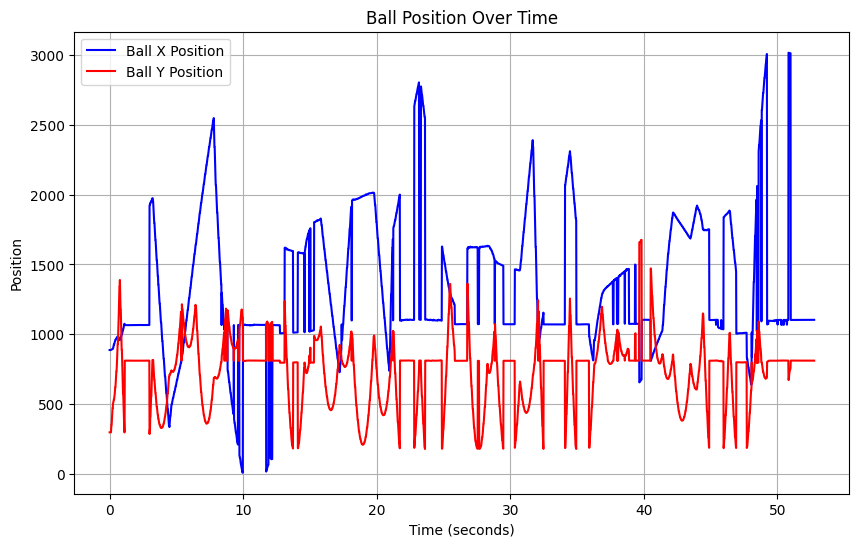

In [ ]:
# Visualization: Ball Position Over Time
import matplotlib.pyplot as plt

# Filter out rows with missing ball positions and low confidence
df_filtered = df.dropna(subset=['ball_x', 'ball_y'])
df_filtered = df_filtered[df_filtered['ball_confidence'] >= 0.75]

plt.figure(figsize=(10, 6))
plt.plot(df_filtered['timestamp_seconds'], df_filtered['ball_x'], label='Ball X Position', color='blue')
plt.plot(df_filtered['timestamp_seconds'], df_filtered['ball_y'], label='Ball Y Position', color='red')
plt.xlabel('Time (seconds)')
plt.ylabel('Position')
plt.title('Ball Position Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def resolve_duplicates(df):
    # Sort by timestamp to ensure chronological order
    df = df.sort_values(by='timestamp_seconds').reset_index(drop=True)

    # Initialize a list to store the cleaned data
    cleaned_data = []

    # Iterate through the DataFrame
    previous_ball_x, previous_ball_y = None, None
    for timestamp, group in df.groupby('timestamp_seconds'):
        if len(group) == 1:
            # If only one ball detected, keep it
            cleaned_data.append(group.iloc[0])
            previous_ball_x, previous_ball_y = group.iloc[0]['ball_x'], group.iloc[0]['ball_y']
        else:
            # If multiple balls detected, find the one closest to the previous ball
            if previous_ball_x is not None and previous_ball_y is not None:
                group['distance'] = group.apply(
                    lambda row: ((row['ball_x'] - previous_ball_x) ** 2 + (row['ball_y'] - previous_ball_y) ** 2) ** 0.5,
                    axis=1
                )
                closest_ball = group.loc[group['distance'].idxmin()]
                cleaned_data.append(closest_ball)
                previous_ball_x, previous_ball_y = closest_ball['ball_x'], closest_ball['ball_y']
            else:
                # If it's the first timestamp with duplicates, keep all
                cleaned_data.append(group.iloc[0])
                previous_ball_x, previous_ball_y = group.iloc[0]['ball_x'], group.iloc[0]['ball_y']

    # Create a new DataFrame from the cleaned data
    cleaned_df = pd.DataFrame(cleaned_data).drop(columns=['distance'], errors='ignore').reset_index(drop=True)
    return cleaned_df

# Check for duplicate ball detections at the same time
duplicates = df.groupby('timestamp_seconds').size()
duplicates = duplicates[duplicates > 1]

# Print timestamps with duplicate balls
if not duplicates.empty:
    print("Timestamps with duplicate ball detections:")
    print(duplicates)

    df_cleaned = resolve_duplicates(df)
    print(df_cleaned.head(20))

else:
    print("No duplicate ball detections found.")

    

No duplicate ball detections found.


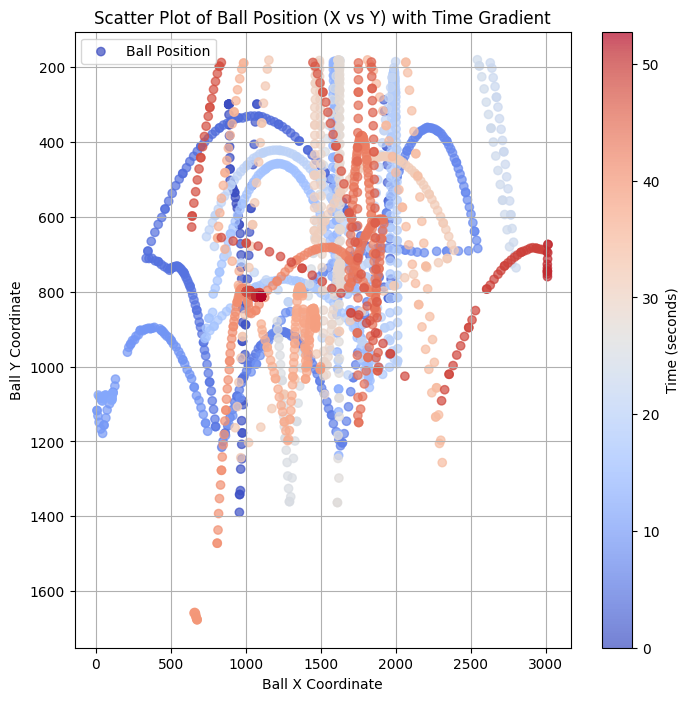

In [47]:
# Scatter Plot: Ball's X vs Y Coordinates with Time Gradient
plt.figure(figsize=(8, 8))

# Use a color gradient based on the timestamp
scatter = plt.scatter(
    df_filtered['ball_x'], 
    df_filtered['ball_y'], 
    c=df_filtered['timestamp_seconds'], 
    cmap='coolwarm',  # Gradient from blue to red
    alpha=0.7, 
    label='Ball Position'
)

# Add a colorbar to show the time gradient
cbar = plt.colorbar(scatter)
cbar.set_label('Time (seconds)')

plt.xlabel('Ball X Coordinate')
plt.ylabel('Ball Y Coordinate')
plt.title('Scatter Plot of Ball Position (X vs Y) with Time Gradient')
plt.grid(True)
plt.legend()

# Flip the y-axis to display high-to-low values
plt.gca().invert_yaxis()

plt.show()

In [48]:
cut_df = df[(df['timestamp_seconds'] <= 5)]
cut_df.head()

,frame_index,timestamp_seconds,ball_x,ball_y,ball_confidence,ball_class_id
0,0,0.000000,888.089630,299.073029,0.844552,0.0
1,1,0.016703,888.088928,299.070953,0.844479,0.0
2,2,0.033407,888.091095,299.072083,0.844542,0.0
3,3,0.050110,888.093231,299.071869,0.844608,0.0
4,4,0.066814,888.094513,299.071014,0.844635,0.0


In [57]:
# Filter the DataFrame for rows where timestamp_seconds is between 1 and 3
filtered_df = cut_df[(cut_df['timestamp_seconds'] >= 2.95) & (cut_df['timestamp_seconds'] <= 3.15)]

# Print the filtered DataFrame
print("Filtered DataFrame:")
print(filtered_df)

Filtered DataFrame:
     frame_index  timestamp_seconds       ball_x      ball_y  ball_confidence  \
177          177           2.956518  1066.915588  812.037323         0.727642   
178          178           2.973222  1066.882385  812.043427         0.727484   
179          179           2.989925  1921.401917  287.144272         0.853597   
180          180           3.006629  1926.989075  318.201614         0.845608   
181          181           3.023332  1926.979004  318.202896         0.845713   
182          182           3.040036  1939.327759  411.229706         0.861816   
183          183           3.056739  1939.318909  411.248093         0.861332   
184          184           3.073443  1943.111450  460.637863         0.867000   
185          185           3.090146  1946.155945  507.852402         0.858806   
186          186           3.106850  1952.182556  557.118652         0.847879   
187          187           3.123553  1952.190918  557.114502         0.847967   
188     

In [56]:
# Check the time difference for frames 178 and 179
print("Time difference between frames 178 and 179:")
print(cut_df.loc[cut_df['frame_index'].isin([178, 179]), ['frame_index', 'timestamp_seconds', 'time_diff']])

Time difference between frames 178 and 179:
     frame_index  timestamp_seconds  time_diff
178          178           2.973222   0.016703
179          179           2.989925   0.016703


# Step 1: Find edges, plot

Screen cutoff points:
x_min (left edge): 337.14239501953125
x_max (right edge): 1974.2540893554688
y_min (top edge): 287.14427185058594
y_max (bottom edge): 1389.296630859375


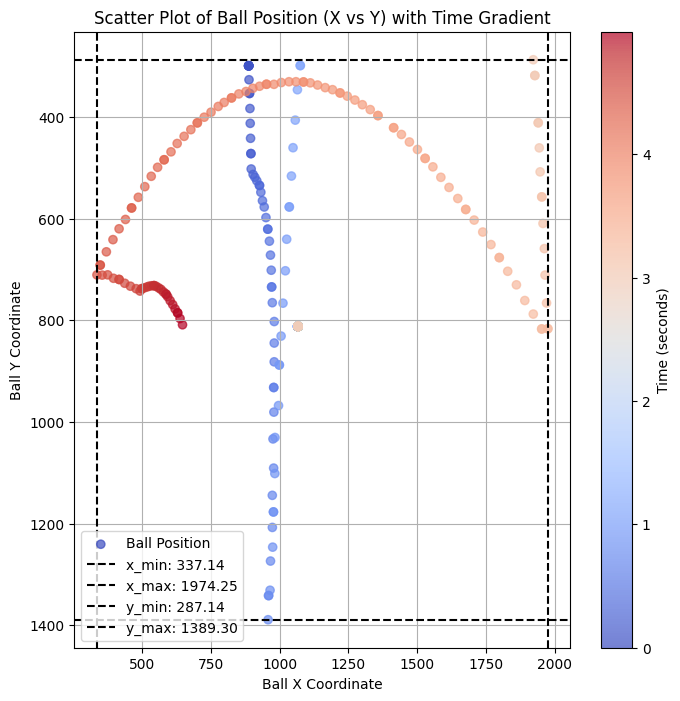

In [49]:
# Calculate the cutoff points as the min and max of x and y variables
x_min = cut_df['ball_x'].min()
x_max = cut_df['ball_x'].max()
y_min = cut_df['ball_y'].min()
y_max = cut_df['ball_y'].max()

# Print the cutoff points
print("Screen cutoff points:")
print(f"x_min (left edge): {x_min}")
print(f"x_max (right edge): {x_max}")
print(f"y_min (top edge): {y_min}")
print(f"y_max (bottom edge): {y_max}")

# Scatter Plot: Ball's X vs Y Coordinates with Time Gradient
plt.figure(figsize=(8, 8))

# Use a color gradient based on the timestamp
scatter = plt.scatter(
    cut_df['ball_x'], 
    cut_df['ball_y'], 
    c=cut_df['timestamp_seconds'], 
    cmap='coolwarm',  # Gradient from blue to red
    alpha=0.7, 
    label='Ball Position'
)

# Add a colorbar to show the time gradient
cbar = plt.colorbar(scatter)
cbar.set_label('Time (seconds)')

# Plot the boundaries
plt.axvline(x=x_min, color='black', linestyle='--', label=f'x_min: {x_min:.2f}')
plt.axvline(x=x_max, color='black', linestyle='--', label=f'x_max: {x_max:.2f}')
plt.axhline(y=y_min, color='black', linestyle='--', label=f'y_min: {y_min:.2f}')
plt.axhline(y=y_max, color='black', linestyle='--', label=f'y_max: {y_max:.2f}')

plt.xlabel('Ball X Coordinate')
plt.ylabel('Ball Y Coordinate')
plt.title('Scatter Plot of Ball Position (X vs Y) with Time Gradient')
plt.grid(True)
plt.legend()

# Flip the y-axis to display high-to-low values
plt.gca().invert_yaxis()

plt.show()

# Find real cut-off points and contact points

Before Points (Exits):
No before points found.
After Points (Re-entries):
No after points found.


/var/folders/x6/l7lxx4tx20vdcmk671bzbxs40000gn/T/ipykernel_3071/3461487220.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cut_df['time_diff'] = cut_df['timestamp_seconds'].diff().abs()


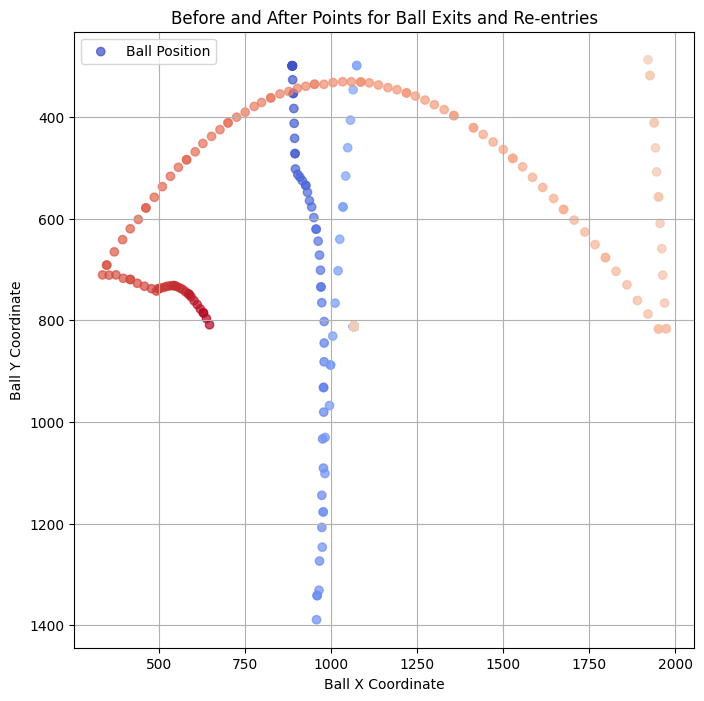

In [51]:
# Define thresholds
time_gap_threshold = 0.5  # Time in seconds to consider a large time jump
edge_threshold = 10  # Distance from the edge to consider "near the edge"

# Calculate time differences
cut_df['time_diff'] = cut_df['timestamp_seconds'].diff().abs()

# Initialize lists to store "Before" and "After" points
before_points = []
after_points = []

# Iterate through the DataFrame to find large time jumps
for i in range(len(cut_df) - 1):
    if cut_df['time_diff'].iloc[i] > time_gap_threshold:
        # Point i is the "Before" point
        before_point = cut_df.iloc[i]
        # Point i+1 is the "After" point
        after_point = cut_df.iloc[i + 1]

        # Validate "Before" point proximity to boundaries
        if (
            (abs(before_point['ball_x'] - x_min) <= edge_threshold) or
            (abs(before_point['ball_x'] - x_max) <= edge_threshold) or
            (abs(before_point['ball_y'] - y_min) <= edge_threshold) or
            (abs(before_point['ball_y'] - y_max) <= edge_threshold)
        ):
            # Validate "After" point proximity to boundaries
            if (
                (abs(after_point['ball_x'] - x_min) <= edge_threshold) or
                (abs(after_point['ball_x'] - x_max) <= edge_threshold) or
                (abs(after_point['ball_y'] - y_min) <= edge_threshold) or
                (abs(after_point['ball_y'] - y_max) <= edge_threshold)
            ):
                # Add validated points to the lists as dictionaries
                before_points.append(before_point.to_dict())
                after_points.append(after_point.to_dict())

# Convert lists to DataFrames for easier handling
before_points_df = pd.DataFrame(before_points)
after_points_df = pd.DataFrame(after_points)

# Print the results
print("Before Points (Exits):")
if not before_points_df.empty:
    print(before_points_df[['frame_index', 'timestamp_seconds', 'ball_x', 'ball_y']])
else:
    print("No before points found.")

print("After Points (Re-entries):")
if not after_points_df.empty:
    print(after_points_df[['frame_index', 'timestamp_seconds', 'ball_x', 'ball_y']])
else:
    print("No after points found.")

# Visualize the "Before" and "After" points
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(cut_df['ball_x'], cut_df['ball_y'], c=cut_df['timestamp_seconds'], cmap='coolwarm', alpha=0.7, label='Ball Position')

if not before_points_df.empty:
    plt.scatter(before_points_df['ball_x'], before_points_df['ball_y'], color='blue', label='Before Points (Exits)', edgecolor='black')

if not after_points_df.empty:
    plt.scatter(after_points_df['ball_x'], after_points_df['ball_y'], color='green', label='After Points (Re-entries)', edgecolor='black')

plt.xlabel('Ball X Coordinate')
plt.ylabel('Ball Y Coordinate')
plt.title('Before and After Points for Ball Exits and Re-entries')
plt.legend()
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()

In [27]:
import numpy as np

distance_threshold = 50  

cut_df['distance_prev'] = np.sqrt(
    (cut_df['ball_x'] - cut_df['ball_x'].shift(1))**2 +
    (cut_df['ball_y'] - cut_df['ball_y'].shift(1))**2
)

cut_df['distance_next'] = np.sqrt(
    (cut_df['ball_x'] - cut_df['ball_x'].shift(-1))**2 +
    (cut_df['ball_y'] - cut_df['ball_y'].shift(-1))**2
)

# Keep only points that have a close-by point either before or after
cut_df_cleaned = cut_df[
    (cut_df['distance_prev'] <= distance_threshold) &
    (cut_df['distance_next'] <= distance_threshold)
].copy()

cut_df_cleaned.drop(columns=['distance_prev', 'distance_next'], inplace=True)

print("Cleaned DataFrame:")
print(cut_df_cleaned)

Cleaned DataFrame:
     frame_index  timestamp_seconds      ball_x      ball_y  ball_confidence  \
1              1           0.016703  888.088928  299.070953         0.844479   
2              2           0.033407  888.091095  299.072083         0.844542   
3              3           0.050110  888.093231  299.071869         0.844608   
4              4           0.066814  888.094513  299.071014         0.844635   
5              5           0.083517  888.092163  299.070648         0.844627   
..           ...                ...         ...         ...              ...   
294          294           4.910827  612.153778  769.050232         0.850818   
295          295           4.927531  620.835632  777.559967         0.863752   
296          296           4.944234  630.056366  785.371765         0.860909   
297          297           4.960938  630.061951  785.322906         0.861458   
298          298           4.977641  638.830841  796.492462         0.855572   

     ball_class_id  

/var/folders/x6/l7lxx4tx20vdcmk671bzbxs40000gn/T/ipykernel_3071/2757337065.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cut_df['distance_prev'] = np.sqrt(
/var/folders/x6/l7lxx4tx20vdcmk671bzbxs40000gn/T/ipykernel_3071/2757337065.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cut_df['distance_next'] = np.sqrt(


Detected Relative Maximums:
     frame_index  timestamp_seconds       ball_x       ball_y  ball_confidence
46            46           0.768361   958.499542  1389.296631         0.810936
70            70           1.169245  1067.294739   812.186371         0.709533
82            82           1.369686  1066.124451   812.223877         0.667432
195          195           3.257181  1951.922119   817.046661         0.817081
277          277           4.626868   493.550385   742.434387         0.865137


/var/folders/x6/l7lxx4tx20vdcmk671bzbxs40000gn/T/ipykernel_3071/1673801039.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cut_df['off_screen'] = False
/var/folders/x6/l7lxx4tx20vdcmk671bzbxs40000gn/T/ipykernel_3071/1673801039.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cut_df['off_screen'] |= near_left_edge & (cut_df['timestamp_seconds'].diff() > time_gap_threshold)
/var/folders/x6/l7lxx4tx20vdcmk671bzbxs40000gn/T/ipykernel_3071/1673801039.py:16: SettingWithCopyWarning: 
A value is trying to 

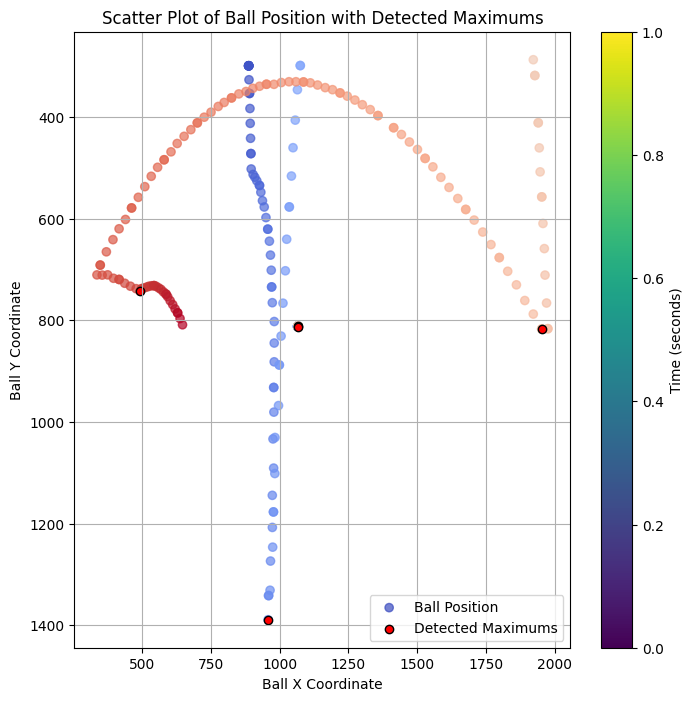

In [31]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Define thresholds for detecting off-screen behavior
time_gap_threshold = 0.5  # Time in seconds to consider the ball as off-screen
edge_threshold = 10  # Distance from the edge to consider the ball as "near the edge"

# Identify points near the edges
near_left_edge = (cut_df['ball_x'] - cut_df['ball_x'].min()).abs() <= edge_threshold
near_right_edge = (cut_df['ball_x'].max() - cut_df['ball_x']).abs() <= edge_threshold
near_top_edge = (cut_df['ball_y'] - cut_df['ball_y'].min()).abs() <= edge_threshold

# Mark points where the ball went off-screen
cut_df['off_screen'] = False
cut_df['off_screen'] |= near_left_edge & (cut_df['timestamp_seconds'].diff() > time_gap_threshold)
cut_df['off_screen'] |= near_right_edge & (cut_df['timestamp_seconds'].diff() > time_gap_threshold)
cut_df['off_screen'] |= near_top_edge & (cut_df['timestamp_seconds'].diff() > time_gap_threshold)

# Filter out points where the ball went off-screen
valid_points = cut_df[~cut_df['off_screen']]

# Find peaks in the data (relative maximums)
# Since we are looking for maximums, we use the data as is (no inversion)
indices, _ = find_peaks(valid_points['ball_y'], prominence=0.5, distance=10)

# Extract the results
relative_maximums = valid_points.iloc[indices]

print("Detected Relative Maximums:")
print(relative_maximums[['frame_index', 'timestamp_seconds', 'ball_x', 'ball_y', 'ball_confidence']])

# Scatter plot with detected maximums highlighted
plt.figure(figsize=(8, 8))

# Plot all points
plt.scatter(cut_df['ball_x'], cut_df['ball_y'], c=cut_df['timestamp_seconds'], cmap='coolwarm', alpha=0.7, label='Ball Position')

# Highlight detected maximums
plt.scatter(relative_maximums['ball_x'], relative_maximums['ball_y'], color='red', label='Detected Maximums', edgecolor='black')

# Add a colorbar to show the time gradient
cbar = plt.colorbar()
cbar.set_label('Time (seconds)')

# Add labels and title
plt.xlabel('Ball X Coordinate')
plt.ylabel('Ball Y Coordinate')
plt.title('Scatter Plot of Ball Position with Detected Maximums')
plt.grid(True)
plt.legend()

# Flip the y-axis to display high-to-low values
plt.gca().invert_yaxis()

# Show the plot
plt.show()

## Clean Outliers 
##### (Points that appear 50 pts away from previous and next ball detection)

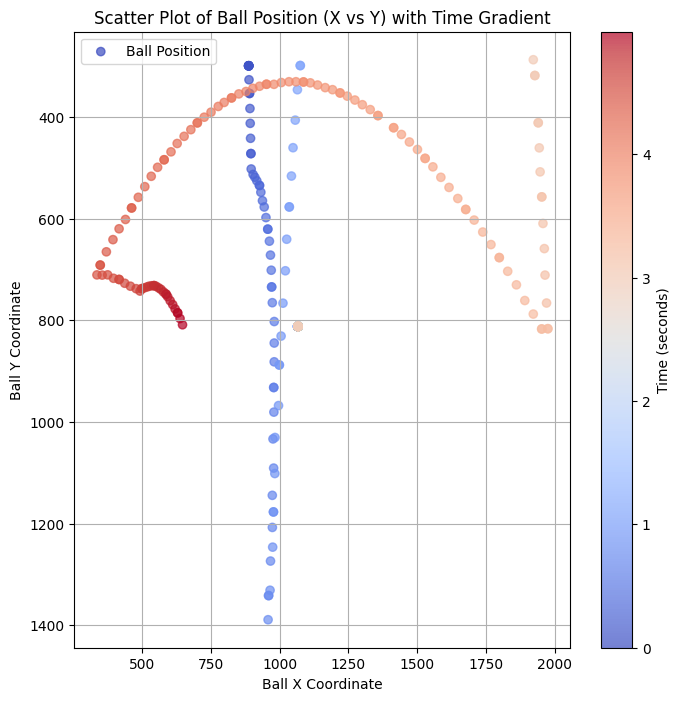

In [100]:
# Scatter Plot: Ball's X vs Y Coordinates with Time Gradient
plt.figure(figsize=(8, 8))

# Use a color gradient based on the timestamp
scatter = plt.scatter(
    cut_df['ball_x'], 
    cut_df['ball_y'], 
    c=cut_df['timestamp_seconds'], 
    cmap='coolwarm',  # Gradient from blue to red
    alpha=0.7, 
    label='Ball Position'
)

# Add a colorbar to show the time gradient
cbar = plt.colorbar(scatter)
cbar.set_label('Time (seconds)')

plt.xlabel('Ball X Coordinate')
plt.ylabel('Ball Y Coordinate')
plt.title('Scatter Plot of Ball Position (X vs Y) with Time Gradient')
plt.grid(True)
plt.legend()

# Flip the y-axis to display high-to-low values
plt.gca().invert_yaxis()

plt.show()

In [77]:
pass1 = 66
set1 = 179
attack1 = 285

# Update 'ball_class_id' based on frame ranges
cut_df.loc[(cut_df['frame_index'] >= pass1) & (cut_df['frame_index'] < set1), 'ball_class_id'] = 1
cut_df.loc[(cut_df['frame_index'] >= set1) & (cut_df['frame_index'] < attack1), 'ball_class_id'] = 2
cut_df.loc[cut_df['frame_index'] >= attack1, 'ball_class_id'] = 3

In [78]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# 1. Define the parabolic model
def parabolic_model(x, a, b, c):
    return a * x**2 + b * x + c

def analyze_trajectories(df):
    """
    Fits parabolas only for passes (1) and sets (2).
    """
    results = {}
    
    # Iterate through the specific labels we care about
    for label_id in [1, 2]:
        label_name = "pass" if label_id == 1 else "set"
        subset = df[df['ball_class_id'] == label_id]

        # We need at least 10 points to define a parabola
        if len(subset) < 10:
            print(f"Not enough data points to fit a curve for {label_name}.")
            continue
            
        x_data = subset['ball_x'].values
        y_data = subset['ball_y'].values

        try:
            # Perform the curve fit
            params, _ = curve_fit(parabolic_model, x_data, y_data)
            results[label_name] = params
            
            a, b, c = params
            print(f"Fitted {label_name}: y = {a:.6f}x^2 + {b:.4f}x + {c:.4f}")
            
        except RuntimeError:
            print(f"Could not converge on a fit for {label_name}.")
            
    return results


In [79]:
# Assuming 'df' is your DataFrame with columns ['x', 'y', 'label']
trajectory_models = analyze_trajectories(cut_df)

Fitted pass: y = -6.780940x^2 + 14465.4857x + -7713835.2166
Fitted set: y = 0.000518x^2 + -1.2315x + 1090.6551


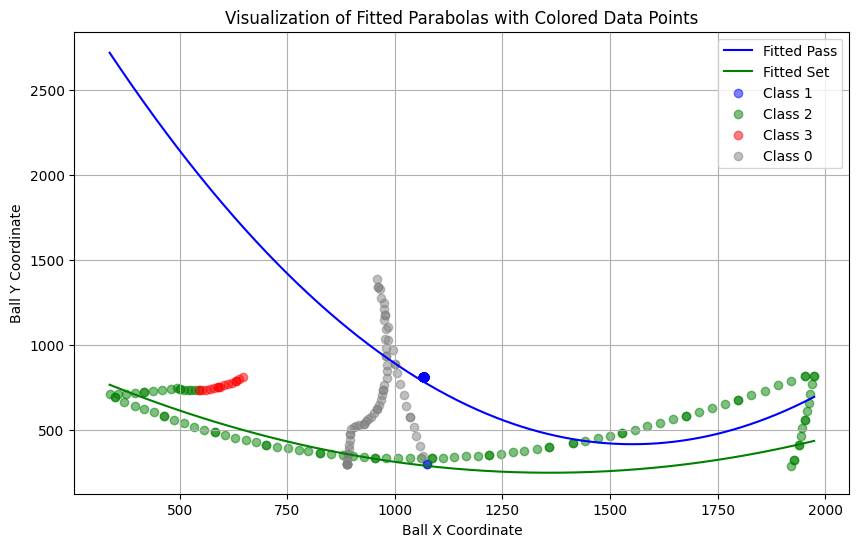

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# Define the fitted parabola equations
pass_params = [0.001563, -4.8509, 4177.8917]
set_params = [0.000496, -1.3484, 1162.5386]

def parabola(x, a, b, c):
    return a * x**2 + b * x + c

# Generate x values for plotting
x_values = np.linspace(cut_df['ball_x'].min(), cut_df['ball_x'].max(), 500)

# Calculate y values for each parabola
pass_y = parabola(x_values, *pass_params)
set_y = parabola(x_values, *set_params)

# Define colors for each class
colors = {1: 'blue', 2: 'green', 3: 'red', 0: 'gray'}  # 1: pass, 2: set, 3: hit, 0: other

# Plot the parabolas
plt.figure(figsize=(10, 6))
plt.plot(x_values, pass_y, label='Fitted Pass', color='blue')
plt.plot(x_values, set_y, label='Fitted Set', color='green')

# Scatter plot of the actual data points, colored by ball_class_id
for class_id, color in colors.items():
    subset = cut_df[cut_df['ball_class_id'] == class_id]
    plt.scatter(subset['ball_x'], subset['ball_y'], alpha=0.5, label=f'Class {class_id}', color=color)

plt.xlabel('Ball X Coordinate')
plt.ylabel('Ball Y Coordinate')
plt.title('Visualization of Fitted Parabolas with Colored Data Points')
plt.legend()
plt.grid(True)
plt.show()

## Velocity Based Approach

In [83]:
# Filter out rows where the ball isn't detected (ball_x or ball_y is NaN)
cut_df_filtered = cut_df.dropna(subset=['ball_x', 'ball_y']).copy()

# Calculate velocity (change in position over time)
cut_df_filtered['velocity_x'] = cut_df_filtered['ball_x'].diff() / cut_df_filtered['timestamp_seconds'].diff()
cut_df_filtered['velocity_y'] = cut_df_filtered['ball_y'].diff() / cut_df_filtered['timestamp_seconds'].diff()
cut_df_filtered['velocity_magnitude'] = np.sqrt(cut_df_filtered['velocity_x']**2 + cut_df_filtered['velocity_y']**2)

# Handle potential NaN values caused by diff()
cut_df_filtered['velocity_magnitude'].fillna(0, inplace=True)

# Define a velocity threshold to identify the start of a pass or set
velocity_mean = cut_df_filtered['velocity_magnitude'].mean()
velocity_std = cut_df_filtered['velocity_magnitude'].std()
velocity_threshold = velocity_mean + velocity_std

# Identify frames where velocity exceeds the threshold
cut_df_filtered['is_transition'] = cut_df_filtered['velocity_magnitude'] > velocity_threshold

# Print frames where transitions occur
transition_frames = cut_df_filtered[cut_df_filtered['is_transition']]
print("Potential start of passes/sets:")
print(transition_frames[['frame_index', 'timestamp_seconds', 'velocity_magnitude']])

# Update 'ball_class_id' based on frame ranges
cut_df_filtered.loc[(cut_df_filtered['frame_index'] >= pass1) & (cut_df_filtered['frame_index'] < set1), 'ball_class_id'] = 1
cut_df_filtered.loc[(cut_df_filtered['frame_index'] >= set1) & (cut_df_filtered['frame_index'] < attack1), 'ball_class_id'] = 2
cut_df_filtered.loc[cut_df_filtered['frame_index'] >= attack1, 'ball_class_id'] = 3

# Analyze trajectories based on velocity-based segmentation
trajectory_models_velocity_based = analyze_trajectories(cut_df_filtered)

Potential start of passes/sets:
     frame_index  timestamp_seconds  velocity_magnitude
68            68           1.135838        30745.539155
179          179           2.989925        60038.776194
182          182           3.040036         5618.156687
Fitted pass: y = -6.780940x^2 + 14465.4857x + -7713835.2166
Fitted set: y = 0.000518x^2 + -1.2315x + 1090.6551


/var/folders/x6/l7lxx4tx20vdcmk671bzbxs40000gn/T/ipykernel_73654/269851378.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cut_df_filtered['velocity_magnitude'].fillna(0, inplace=True)


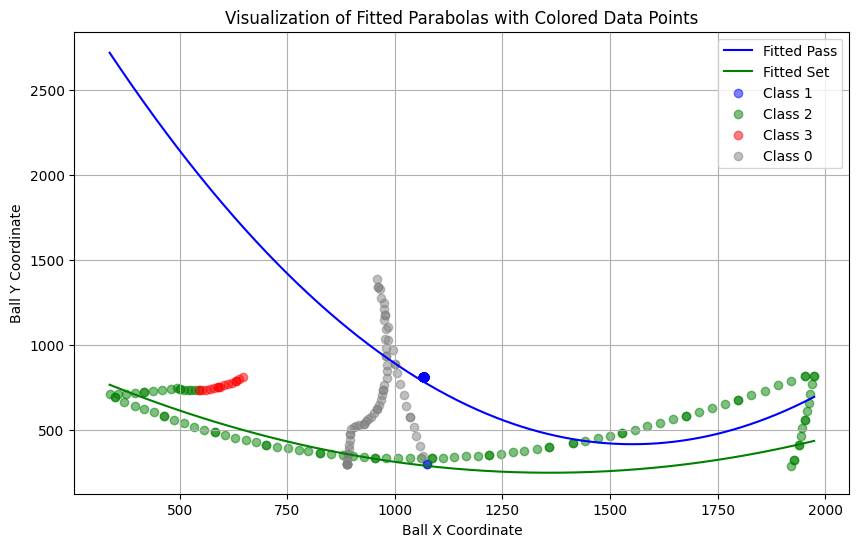

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Define the fitted parabola equations
pass_params = [0.001563, -4.8509, 4177.8917]
set_params = [0.000496, -1.3484, 1162.5386]

def parabola(x, a, b, c):
    return a * x**2 + b * x + c

# Generate x values for plotting
x_values = np.linspace(cut_df['ball_x'].min(), cut_df['ball_x'].max(), 500)

# Calculate y values for each parabola
pass_y = parabola(x_values, *pass_params)
set_y = parabola(x_values, *set_params)

# Define colors for each class
colors = {1: 'blue', 2: 'green', 3: 'red', 0: 'gray'}  # 1: pass, 2: set, 3: hit, 0: other

# Plot the parabolas
plt.figure(figsize=(10, 6))
plt.plot(x_values, pass_y, label='Fitted Pass', color='blue')
plt.plot(x_values, set_y, label='Fitted Set', color='green')

# Scatter plot of the actual data points, colored by ball_class_id
for class_id, color in colors.items():
    subset = cut_df[cut_df['ball_class_id'] == class_id]
    plt.scatter(subset['ball_x'], subset['ball_y'], alpha=0.5, label=f'Class {class_id}', color=color)

plt.xlabel('Ball X Coordinate')
plt.ylabel('Ball Y Coordinate')
plt.title('Visualization of Fitted Parabolas with Colored Data Points')
plt.legend()
plt.grid(True)
plt.show()

## Pivot Approach

In [85]:
import numpy as np

# Calculate differences in x and y positions
cut_df_filtered['delta_x'] = cut_df_filtered['ball_x'].diff()
cut_df_filtered['delta_y'] = cut_df_filtered['ball_y'].diff()

# Calculate angles of movement
cut_df_filtered['angle'] = np.arctan2(cut_df_filtered['delta_y'], cut_df_filtered['delta_x'])

# Calculate the change in angle between consecutive frames
cut_df_filtered['angle_change'] = cut_df_filtered['angle'].diff().abs()

# Define a threshold for significant angle changes (e.g., sharp turns)
angle_threshold = np.pi / 4  # 45 degrees
cut_df_filtered['is_pivot'] = cut_df_filtered['angle_change'] > angle_threshold

# Identify pivot points
pivot_points = cut_df_filtered[cut_df_filtered['is_pivot']]
print("Detected pivot points:")
print(pivot_points[['frame_index', 'timestamp_seconds', 'angle_change']])

Detected pivot points:
     frame_index  timestamp_seconds  angle_change
2              2           0.033407      2.377358
5              5           0.083517      2.398990
6              6           0.100221      1.546599
7              7           0.116924      2.969503
9              9           0.150331      3.638403
..           ...                ...           ...
286          286           4.777199      0.840527
291          291           4.860717      1.802438
292          292           4.877420      1.555072
297          297           4.960938      2.159853
298          298           4.977641      2.362212

[148 rows x 3 columns]


In [86]:
# Calculate velocity magnitude
cut_df_filtered['velocity'] = np.sqrt(cut_df_filtered['delta_x']**2 + cut_df_filtered['delta_y']**2)

# Calculate the change in velocity between consecutive frames
cut_df_filtered['velocity_change'] = cut_df_filtered['velocity'].diff().abs()

# Define a threshold for significant velocity changes
velocity_change_threshold = cut_df_filtered['velocity_change'].mean() + cut_df_filtered['velocity_change'].std()
cut_df_filtered['is_velocity_pivot'] = cut_df_filtered['velocity_change'] > velocity_change_threshold

# Identify velocity pivot points
velocity_pivots = cut_df_filtered[cut_df_filtered['is_velocity_pivot']]
print("Detected velocity pivot points:")
print(velocity_pivots[['frame_index', 'timestamp_seconds', 'velocity_change']])

Detected velocity pivot points:
     frame_index  timestamp_seconds  velocity_change
68            68           1.135838       513.504966
69            69           1.152541       513.343396
179          179           2.989925      1002.823534
180          180           3.006629       971.301393


In [87]:
# Calculate acceleration (change in velocity over time)
cut_df_filtered['acceleration'] = cut_df_filtered['velocity'].diff() / cut_df_filtered['timestamp_seconds'].diff()

# Define a threshold for significant acceleration changes
acceleration_threshold = cut_df_filtered['acceleration'].mean() + cut_df_filtered['acceleration'].std()
cut_df_filtered['is_acceleration_pivot'] = cut_df_filtered['acceleration'].abs() > acceleration_threshold

# Identify acceleration pivot points
acceleration_pivots = cut_df_filtered[cut_df_filtered['is_acceleration_pivot']]
print("Detected acceleration pivot points:")
print(acceleration_pivots[['frame_index', 'timestamp_seconds', 'acceleration']])

Detected acceleration pivot points:
     frame_index  timestamp_seconds  acceleration
68            68           1.135838  30742.369757
69            69           1.152541 -30732.696923
179          179           2.989925  60036.755093
180          180           3.006629 -58149.596483
182          182           3.040036   5617.548908
183          183           3.056739  -5616.935034


In [88]:
# Combine all pivot conditions
cut_df_filtered['is_major_pivot'] = (
    cut_df_filtered['is_pivot'] | 
    cut_df_filtered['is_velocity_pivot'] | 
    cut_df_filtered['is_acceleration_pivot']
)

# Identify major pivot points
major_pivots = cut_df_filtered[cut_df_filtered['is_major_pivot']]
print("Detected major pivot points:")
print(major_pivots[['frame_index', 'timestamp_seconds', 'angle_change', 'velocity_change', 'acceleration']])

Detected major pivot points:
     frame_index  timestamp_seconds  angle_change  velocity_change  \
2              2           0.033407      2.377358         0.000253   
5              5           0.083517      2.398990         0.000838   
6              6           0.100221      1.546599         0.000438   
7              7           0.116924      2.969503        27.517613   
9              9           0.150331      3.638403        27.013155   
..           ...                ...           ...              ...   
286          286           4.777199      0.840527         7.878909   
291          291           4.860717      1.802438        10.270257   
292          292           4.877420      1.555072         7.805252   
297          297           4.960938      2.159853        12.035777   
298          298           4.977641      2.362212        14.151260   

     acceleration  
2        0.015124  
5        0.050155  
6        0.026225  
7     1647.416629  
9    -1617.215909  
..        

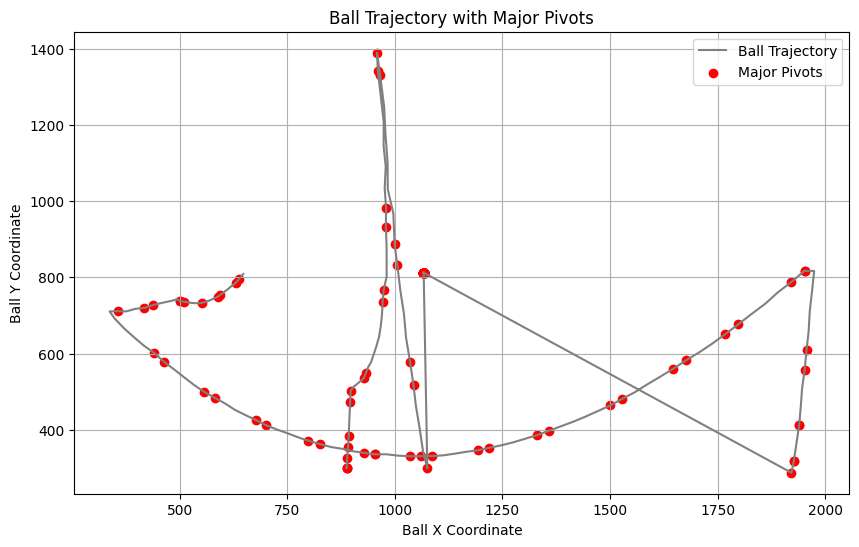

In [89]:
# Plot the ball trajectory
plt.figure(figsize=(10, 6))
plt.plot(cut_df_filtered['ball_x'], cut_df_filtered['ball_y'], label='Ball Trajectory', color='gray')

# Highlight major pivot points
plt.scatter(major_pivots['ball_x'], major_pivots['ball_y'], color='red', label='Major Pivots')

plt.xlabel('Ball X Coordinate')
plt.ylabel('Ball Y Coordinate')
plt.title('Ball Trajectory with Major Pivots')
plt.legend()
plt.grid(True)
plt.show()